In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
telco_data = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(telco_data.shape)
telco_data.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
telco_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [14]:
missing_values = telco_data.isnull().sum()
missing_values

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [15]:
empty_values = (telco_data == "").sum()
empty_values

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [17]:
print(telco_data.duplicated().sum())
print(telco_data["customerID"].duplicated().sum())

0
0


In [18]:
unique_counts = telco_data.nunique().sort_values()
unique_counts

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
PhoneService           2
PaperlessBilling       2
Churn                  2
MultipleLines          3
TechSupport            3
StreamingTV            3
OnlineBackup           3
DeviceProtection       3
StreamingMovies        3
Contract               3
OnlineSecurity         3
InternetService        3
PaymentMethod          4
tenure                73
MonthlyCharges      1585
TotalCharges        6531
customerID          7043
dtype: int64

In [19]:
telco_data.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [21]:
telco_data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Churn Distribution

In [23]:
churn_percentage = (telco_data["Churn"].value_counts(normalize=True).mul(100).round(2))
churn_percentage

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

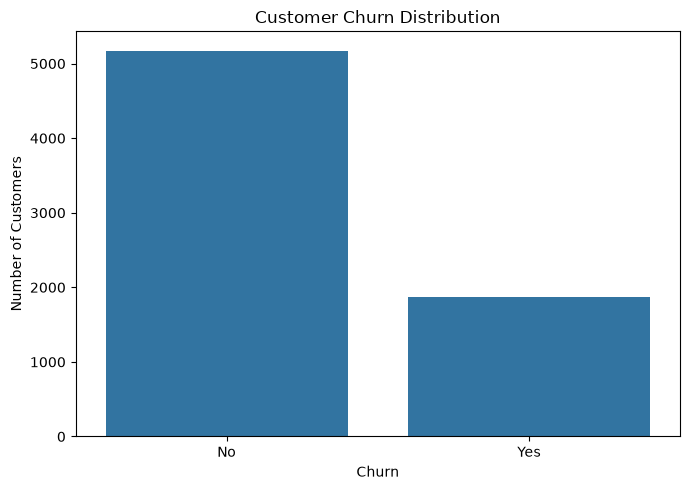

In [24]:
plt.figure(figsize=(7, 5))
sns.countplot(data=telco_data, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

### Numerical Feature Distribution

In [25]:
numeric_columns = telco_data.select_dtypes(include=np.number).columns.tolist()
numeric_columns

['SeniorCitizen', 'tenure', 'MonthlyCharges']

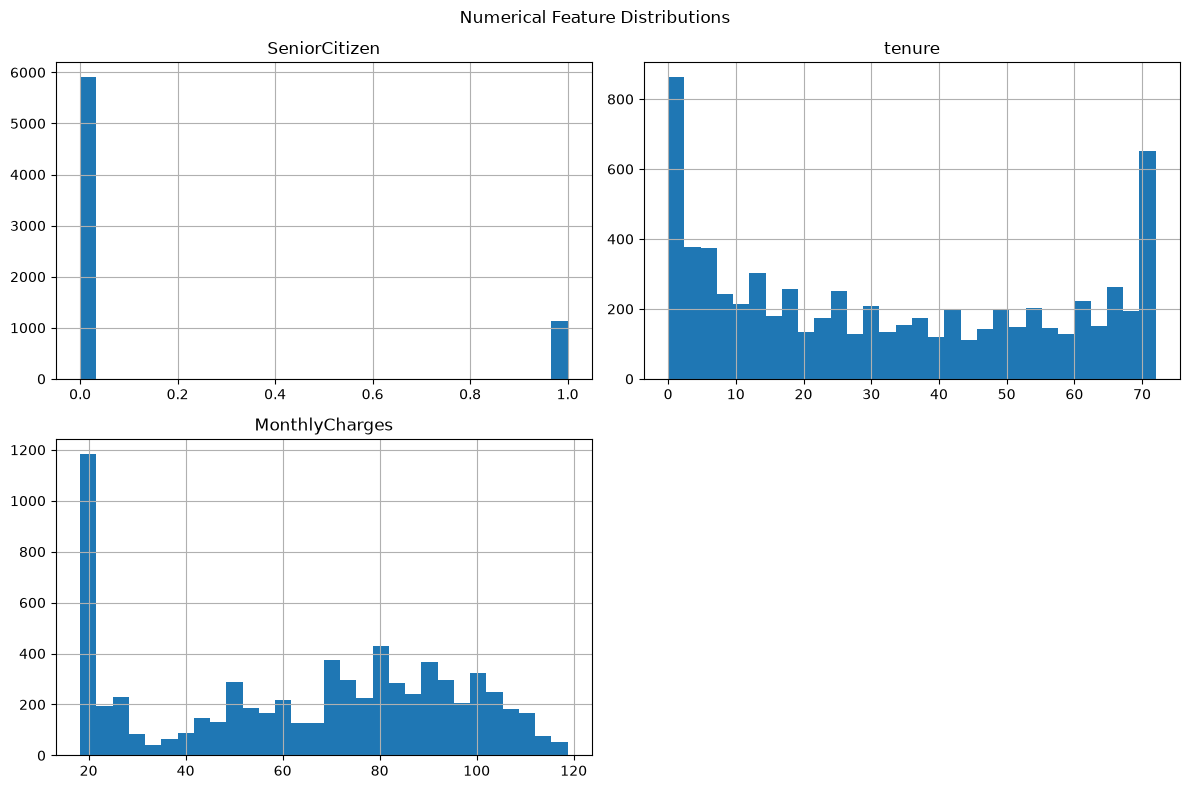

In [26]:
telco_data[numeric_columns].hist(figsize=(12, 8), bins=30)
plt.suptitle("Numerical Feature Distributions")
plt.tight_layout()
plt.show()

### Contract Type Distribution

In [27]:
print(telco_data["Contract"].value_counts())

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64


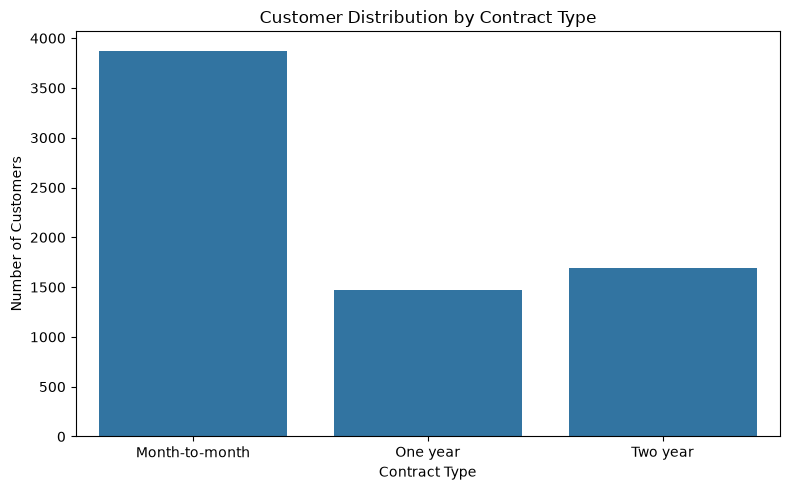

In [28]:
plt.figure(figsize=(8, 5))
sns.countplot(data=telco_data, x="Contract")
plt.title("Customer Distribution by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

### Categorical distributions + Churn relationships

In [29]:
categorical_columns = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

for column in categorical_columns:
    print(telco_data[column].value_counts())

gender
Male      3555
Female    3488
Name: count, dtype: int64
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64
TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64
StreamingTV
No                     2810
Y

#### Churn by important categories

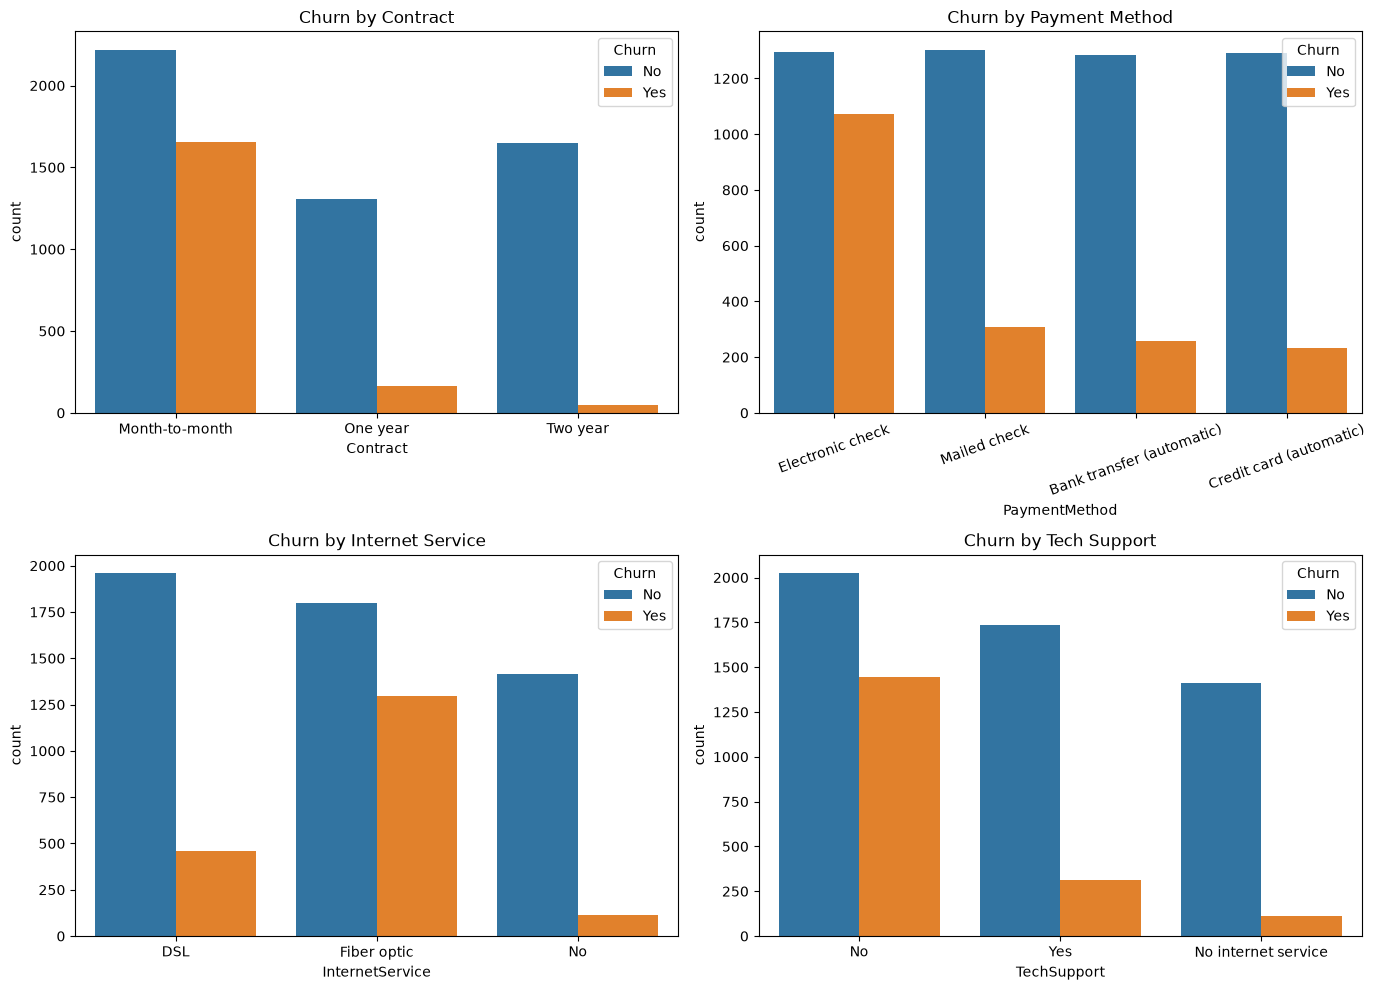

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=telco_data, x="Contract", hue="Churn", ax=axes[0, 0])
axes[0, 0].set_title("Churn by Contract")

sns.countplot(data=telco_data, x="PaymentMethod", hue="Churn", ax=axes[0, 1])
axes[0, 1].set_title("Churn by Payment Method")
axes[0, 1].tick_params(axis="x", rotation=20)

sns.countplot(data=telco_data, x="InternetService", hue="Churn", ax=axes[1, 0])
axes[1, 0].set_title("Churn by Internet Service")

sns.countplot(data=telco_data, x="TechSupport", hue="Churn", ax=axes[1, 1])
axes[1, 1].set_title("Churn by Tech Support")

plt.tight_layout()
plt.show()

#### Tenure and Monthly Charges vs Churn

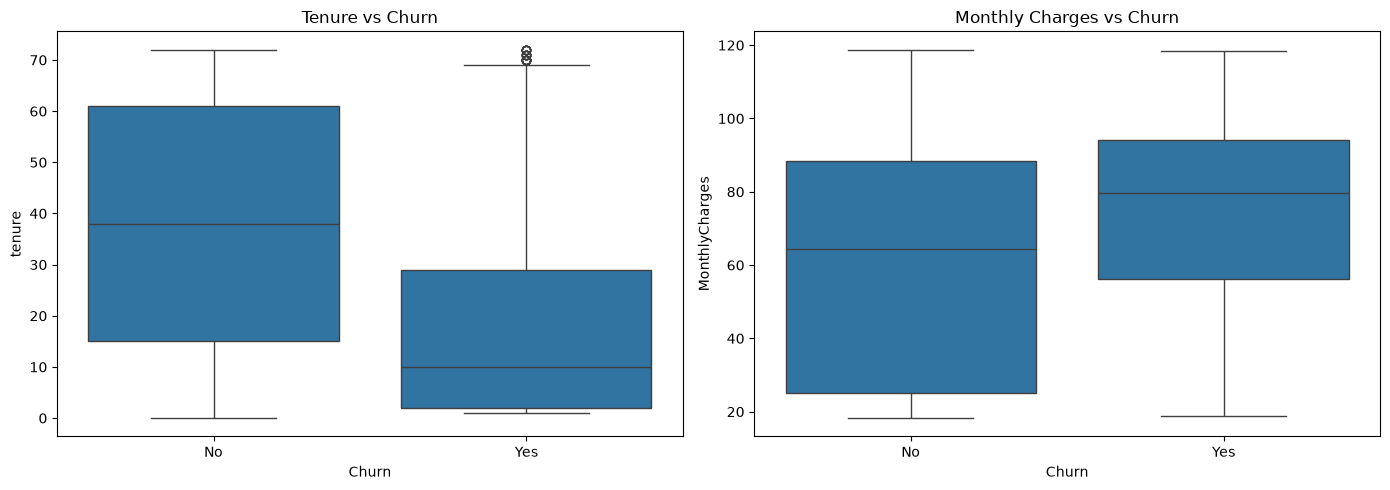

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=telco_data, x="Churn", y="tenure", ax=axes[0])
axes[0].set_title("Tenure vs Churn")

sns.boxplot(data=telco_data, x="Churn", y="MonthlyCharges", ax=axes[1])
axes[1].set_title("Monthly Charges vs Churn")

plt.tight_layout()
plt.show()

#### Correlation analysis

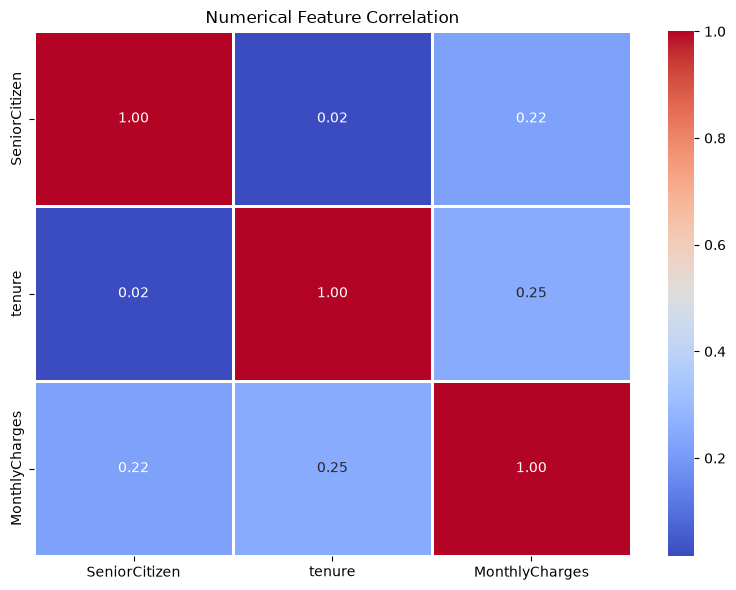

In [33]:
correlation = telco_data.select_dtypes(include=np.number).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation,
    annot=True,
    linewidth = 1,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Numerical Feature Correlation")
plt.tight_layout()
plt.show()

In [35]:
print("Dataset Shape:", telco_data.shape)

print("\nChurn:")
print(telco_data["Churn"].value_counts())

print("\nAverage Monthly Charges by Churn:")
print(telco_data.groupby("Churn")["MonthlyCharges"].mean().round(2))

print("\nAverage Tenure by Churn:")
print(telco_data.groupby("Churn")["tenure"].mean().round(2))


total_charges_numeric = pd.to_numeric(
    telco_data["TotalCharges"],
    errors="coerce"
)

print("Average Total Charges by Churn:")
print(
    total_charges_numeric
    .groupby(telco_data["Churn"])
    .mean()
    .round(2)
)

Dataset Shape: (7043, 21)

Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Average Monthly Charges by Churn:
Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64

Average Tenure by Churn:
Churn
No     37.57
Yes    17.98
Name: tenure, dtype: float64

Average Total Charges by Churn:
Average Total Charges by Churn:
Churn
No     2555.34
Yes    1531.80
Name: TotalCharges, dtype: float64
